# Copernicus: Seasonal & Sub-seasonal Forecasts over Africa

**Last updated:** 2026-05-11

---

## Learning objectives

1. Understand the seasonal → sub-seasonal → medium-range forecast chain for early warning
2. Access ECMWF SEAS5 seasonal forecasts via CDS and compute precipitation anomalies
3. Access ECMWF S2S sub-seasonal forecasts via CDS for 2-6 week outlooks
4. Plot ensemble mean, anomalies, and spread over Africa
5. Understand how each timescale feeds into IbF anticipatory action

---

## Introduction

Early warning systems need forecasts at **multiple timescales**: each answers a different question:

| Timescale | Product | Question answered |
|---|---|---|
| 1-7 months | SEAS5 seasonal | Is this a drought / flood season? |
| 2-6 weeks | S2S sub-seasonal | Which weeks are anomalously wet or dry? |
| 0-15 days | IFS / AIFS | When exactly does the event hit? |
| 0-6 hours | AMSAF nowcasting | Where exactly, right now? |

This notebook covers the first two: **seasonal (SEAS5)** and **sub-seasonal (S2S)**.
See notebooks 01/03 for medium-range open data.

### Relevance to SEWA hazards

| Region | Hazard | Signal |
|---|---|---|
| Eastern Africa | Drought / dry spells | Below-normal precipitation, weeks-months ahead |
| Western Africa | Heatwaves | Above-normal temperature, seasonal outlook |
| Southern Africa | Drought, tropical cyclones | Below-normal precip, SST anomalies |
| All regions | Flood season onset | Above-normal precipitation probability |

> **Prerequisites:** 05 (CDS setup), `~/.cdsapirc` configured  
> **Licences required (one-time):** Accept on CDS before running: see notes below each download cell  
> **Run time:** ~10 min first run (downloads ~50 MB total), instant on subsequent runs  


## 1) Setup


In [1]:
import cdsapi
import earthkit.data as ekd
import earthkit.plots as ekp
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from datetime import datetime

from _utils import get_data_dir
DATA_DIR = get_data_dir()

c = cdsapi.Client(quiet=True)
print('CDS client ready')
print('Data cache:', DATA_DIR)

# Target: forecast initialised this month, lead times 1-3 months
now = datetime.utcnow()
FCST_YEAR  = str(now.year)
FCST_MONTH = f'{now.month:02d}'
print(f'Forecast start: {FCST_YEAR}-{FCST_MONTH}')


CDS client ready
Data cache: /Users/valtze/ecmwf-open-data-guide/data
Forecast start: 2026-07


## 2) Download SEAS5 forecast: monthly precipitation

We fetch monthly mean total precipitation for Africa,
for lead times 1, 2, and 3 months ahead.
All 51 ensemble members are included so we can compute spread.

**First run:** downloads ~15 MB from CDS (takes ~2 min)  
**Subsequent runs:** loads from cache instantly


⚠️ Licence required: accept before running

SEAS5 and ERA5 monthly means each require a one-time licence acceptance on CDS:

1. **SEAS5:** [Accept licence here](https://cds.climate.copernicus.eu/datasets/seasonal-monthly-single-levels?tab=download#manage-licences)
2. **ERA5 monthly means:** [Accept licence here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=download#manage-licences)

If you see `403 Forbidden: required licences not accepted`, visit the links above, log in, and click Accept.


In [2]:
seas5_fc_path = DATA_DIR / f'seas5_tp_africa_{FCST_YEAR}{FCST_MONTH}.grib'

if not seas5_fc_path.exists():
    print('Downloading SEAS5 forecast... (first run, ~2 min)')
    c.retrieve(
        'seasonal-monthly-single-levels',
        {
            'originating_centre': 'ecmwf',
            'system': '51',
            'variable': 'total_precipitation',
            'product_type': 'monthly_mean',
            'year': FCST_YEAR,
            'month': FCST_MONTH,
            'leadtime_month': ['1', '2', '3'],
            'area': [40, -20, -40, 55],  # N, W, S, E: sub-Saharan Africa
            'data_format': 'grib',
        },
        str(seas5_fc_path)
    )
    print(f'Downloaded: {seas5_fc_path} ({seas5_fc_path.stat().st_size/1e6:.1f} MB)')
else:
    print(f'Using cached file: {seas5_fc_path}')


f5681a2dc58e98d45d5bd5d792d11ee3.grib:   0%|          | 0.00/1.77M [00:00<?, ?B/s]

Downloaded: /Users/valtze/ecmwf-open-data-guide/data/seas5_tp_africa_202607.grib (1.9 MB)


## 3) Download ERA5 climatology: 1993 - 2016 reference period

To compute anomalies we need a historical baseline.
We use ERA5 monthly precipitation over the same Africa domain,
for the standard WMO climatology period 1993-2016 (matching SEAS5 hindcast period).

**First run:** downloads ~15 MB from CDS  
**Subsequent runs:** loads from cache instantly


In [3]:
era5_clim_path = DATA_DIR / 'era5_tp_africa_clim_1993_2016.grib'

if not era5_clim_path.exists():
    print('Downloading ERA5 climatology... (first run, ~2 min)')
    c.retrieve(
        'reanalysis-era5-single-levels-monthly-means',
        {
            'product_type': 'monthly_averaged_reanalysis',
            'variable': 'total_precipitation',
            'year': [str(y) for y in range(1993, 2017)],
            'month': [f'{m:02d}' for m in range(1, 13)],
            'time': '00:00',
            'area': [40, -20, -40, 55],
            'data_format': 'grib',
        },
        str(era5_clim_path)
    )
    print(f'Downloaded: {era5_clim_path} ({era5_clim_path.stat().st_size/1e6:.1f} MB)')
else:
    print(f'Using cached file: {era5_clim_path}')


Using cached file: /Users/valtze/ecmwf-open-data-guide/data/era5_tp_africa_clim_1993_2016.grib


## 4) Compute anomalies and plot


In [4]:
# Load forecast and climatology as xarray
ds_fc   = ekd.from_source('file', str(seas5_fc_path)).to_xarray()
ds_clim = ekd.from_source('file', str(era5_clim_path)).to_xarray()

# SEAS5 tp is in metres: convert to mm/day for readability
tp_key = [v for v in ds_fc.data_vars][0]
fc_tp  = ds_fc[tp_key]   # dims: number, step, lat, lon

clim_key = [v for v in ds_clim.data_vars][0]
cl_tp    = ds_clim[clim_key]  # dims: time, lat, lon

print('Forecast shape:', fc_tp.shape)
print('Climatology shape:', cl_tp.shape)
print('Forecast variables:', list(ds_fc.data_vars))


Forecast shape: (51, 3, 80, 75)
Climatology shape: (288, 321, 301)
Forecast variables: ['tprate']


In [5]:
# Ensemble mean across all 51 members for lead month 1
fc_mean = fc_tp.isel(step=0).mean(dim='number') / 1000  # m → mm

# Find the time dimension name: may vary by earthkit/xarray version
time_dim = [d for d in cl_tp.dims if 'time' in d.lower() or 'valid' in d.lower()][0]
print(f'Climatology time dimension: {time_dim}')

# Climatology mean for the target calendar month
target_month = (int(FCST_MONTH) % 12) + 1  # lead 1 = next month
clim_mean = cl_tp.sel(
    {time_dim: cl_tp[time_dim].dt.month == target_month}
).mean(dim=time_dim) / 1000  # m → mm

# Anomaly
anomaly = fc_mean - clim_mean

print(f'Target month: {target_month}')
print(f'Anomaly range: {float(anomaly.min()):.1f} to {float(anomaly.max()):.1f} mm')


Climatology time dimension: forecast_reference_time
Target month: 8
Anomaly range: -0.0 to 0.0 mm


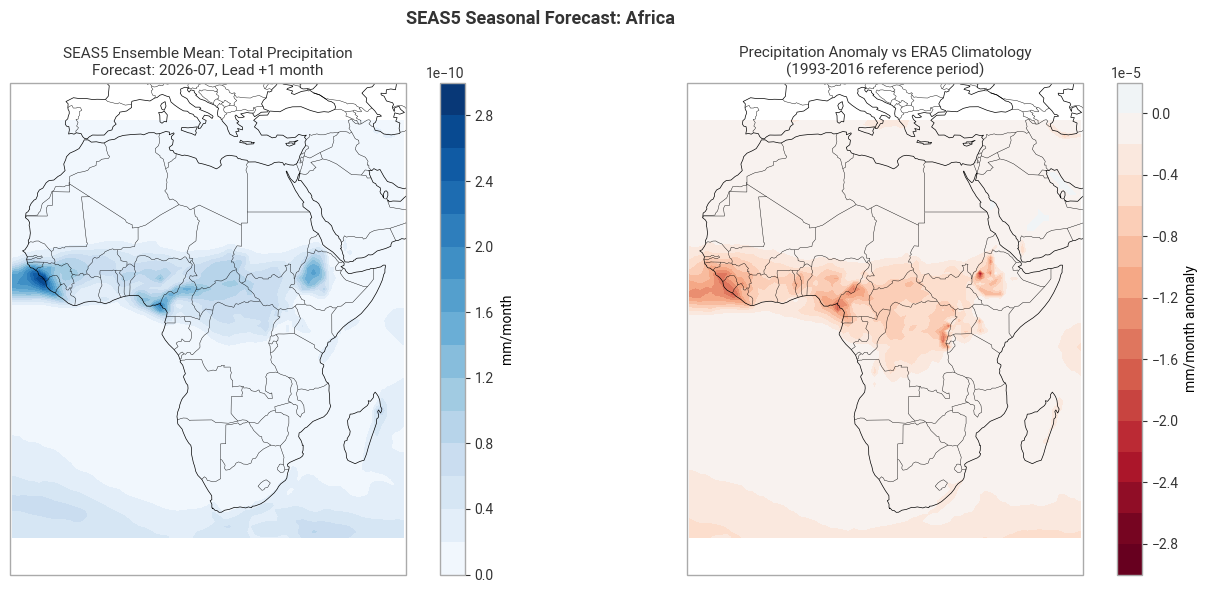

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()})

# Plot 1: Ensemble mean forecast
ax1 = axes[0]
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.3)
im1 = ax1.contourf(fc_mean.longitude, fc_mean.latitude, fc_mean,
    levels=15, cmap='Blues', transform=ccrs.PlateCarree())
plt.colorbar(im1, ax=ax1, label='mm/month')
ax1.set_title(f'SEAS5 Ensemble Mean: Total Precipitation\n'
    f'Forecast: {FCST_YEAR}-{FCST_MONTH}, Lead +1 month', fontsize=11)
ax1.set_extent([-20, 55, -40, 40])

# Plot 2: Anomaly vs ERA5 climatology
ax2 = axes[1]
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.add_feature(cfeature.BORDERS, linewidth=0.3)
lim = max(abs(float(anomaly.min())), abs(float(anomaly.max())))
im2 = ax2.contourf(anomaly.longitude, anomaly.latitude, anomaly,
    levels=15, cmap='RdBu', vmin=-lim, vmax=lim,
    transform=ccrs.PlateCarree())
plt.colorbar(im2, ax=ax2, label='mm/month anomaly')
ax2.set_title(f'Precipitation Anomaly vs ERA5 Climatology\n'
    f'(1993-2016 reference period)', fontsize=11)
ax2.set_extent([-20, 55, -40, 40])

plt.suptitle('SEAS5 Seasonal Forecast: Africa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5) Ensemble spread: uncertainty in the outlook

The spread across 51 ensemble members tells us how confident the forecast is.
Wide spread = high uncertainty. Narrow spread = more confident signal.
For IbF triggers, both the signal strength AND confidence matter.


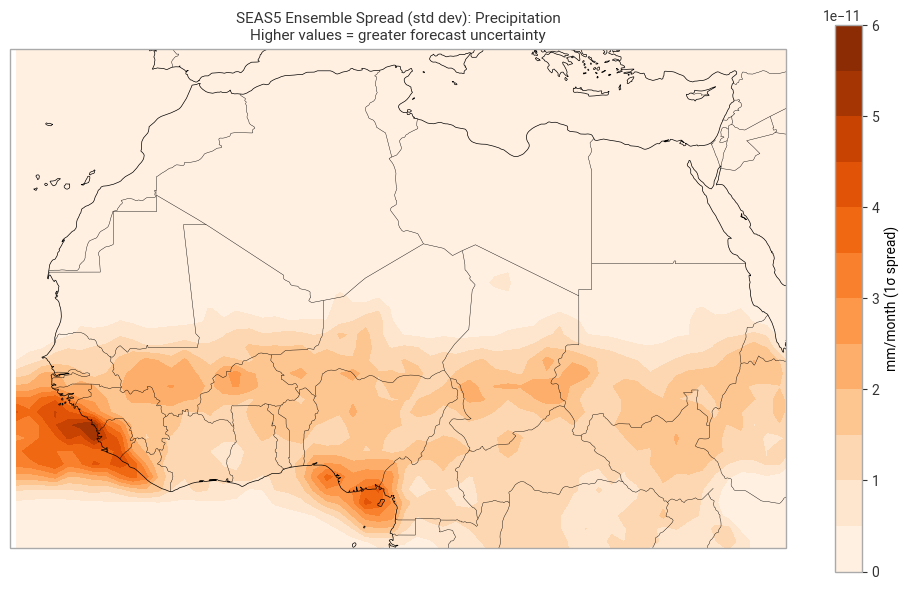

In [7]:
fc_std = fc_tp.isel(step=0).std(dim='number') / 1000  # mm

fig, ax = plt.subplots(figsize=(10, 6),
    subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
im = ax.contourf(fc_std.longitude, fc_std.latitude, fc_std,
    levels=12, cmap='Oranges', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='mm/month (1σ spread)')
ax.set_title('SEAS5 Ensemble Spread (std dev): Precipitation\n'
    'Higher values = greater forecast uncertainty', fontsize=11)
ax.set_extent([-20, 40, 0, 35])
plt.tight_layout()
plt.show()


---

## 6) Sub-seasonal forecasts: S2S (2-6 weeks ahead)

**Sub-seasonal to seasonal (S2S)** forecasts fill the gap between medium-range (15 days)
and seasonal (months). For early warning, S2S is the key layer for **anticipatory action**:
activating protocols 2-4 weeks before an event.

ECMWF contributes to the **WMO S2S database**: ensemble forecasts at 2-week lead times,
available free via CDS.

### ⚠️ Licence required
Accept before running:  
[sub-seasonal-originating-centres licence](https://cds.climate.copernicus.eu/datasets/sub-seasonal-originating-centres?tab=download#manage-licences)

**First run:** downloads ~10 MB (takes ~2 min)  
**Subsequent runs:** loads from cache instantly


In [8]:
from datetime import datetime, timedelta
import cdsapi

# S2S is on ECDS (ecds.ecmwf.int): separate from CDS
# Register free account at: https://ecds.ecmwf.int
# Accept S2S licence at: https://ecds.ecmwf.int/datasets/s2s-forecasts?tab=download#manage-licences
ecds = cdsapi.Client(
    url='https://ecds.ecmwf.int/api',
    quiet=True
)

S2S_DATE = '2026-04-03'  # recent Thursday: S2S available with ~48h delay

s2s_path = DATA_DIR / f's2s_tp_africa_{S2S_DATE.replace("-","")}.grib'

if not s2s_path.exists():
    print('Downloading S2S forecast... (first run, ~2 min)')
    ecds.retrieve(
        's2s-forecasts',
        {
            'origin': 'ecmwf',
            'variable': 'total_precipitation',
            'forecast_type': 'control_forecast',
            'level_type': 'single_level',
            'year': S2S_DATE[:4],
            'month': S2S_DATE[5:7],
            'day': S2S_DATE[8:10],
            'leadtime_hour': ['024', '048', '072', '096',
                              '120', '144', '168', '192',
                              '216', '240', '264', '288',
                              '312', '336', '360', '384'],
            'time': '00:00',
            'area': [40, -20, -40, 55],
            'data_format': 'grib',
        },
        str(s2s_path)
    )
    print(f'Downloaded: {s2s_path} ({s2s_path.stat().st_size/1e6:.1f} MB)')
else:
    print(f'Using cached file: {s2s_path}')

e19329d62061028c6b4864fa9aac0a72.grib:   0%|          | 0.00/86.0k [00:00<?, ?B/s]

Downloaded: /Users/valtze/ecmwf-open-data-guide/data/s2s_tp_africa_20260403.grib (0.1 MB)


In [9]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ds_s2s = ekd.from_source('file', str(s2s_path))
print(ds_s2s.ls())


   centre shortName typeOfLevel  level  dataDate  dataTime stepRange dataType  \
0    ecmf        tp     surface      0  20260403         0      0-24       cf   
1    ecmf        tp     surface      0  20260403         0      0-48       cf   
2    ecmf        tp     surface      0  20260403         0      0-72       cf   
3    ecmf        tp     surface      0  20260403         0      0-96       cf   
4    ecmf        tp     surface      0  20260403         0     0-120       cf   
5    ecmf        tp     surface      0  20260403         0     0-144       cf   
6    ecmf        tp     surface      0  20260403         0     0-168       cf   
7    ecmf        tp     surface      0  20260403         0     0-192       cf   
8    ecmf        tp     surface      0  20260403         0     0-216       cf   
9    ecmf        tp     surface      0  20260403         0     0-240       cf   
10   ecmf        tp     surface      0  20260403         0     0-264       cf   
11   ecmf        tp     surf

In [10]:
da_s2s = ds_s2s.to_xarray()
s2s_key = [v for v in da_s2s.data_vars][0]
s2s_tp = da_s2s[s2s_key]

print('S2S variables:', list(da_s2s.data_vars))
print('S2S shape:', s2s_tp.shape)
print('S2S dims:', s2s_tp.dims)


S2S variables: ['tp']
S2S shape: (16, 53, 50)
S2S dims: ('step', 'latitude', 'longitude')


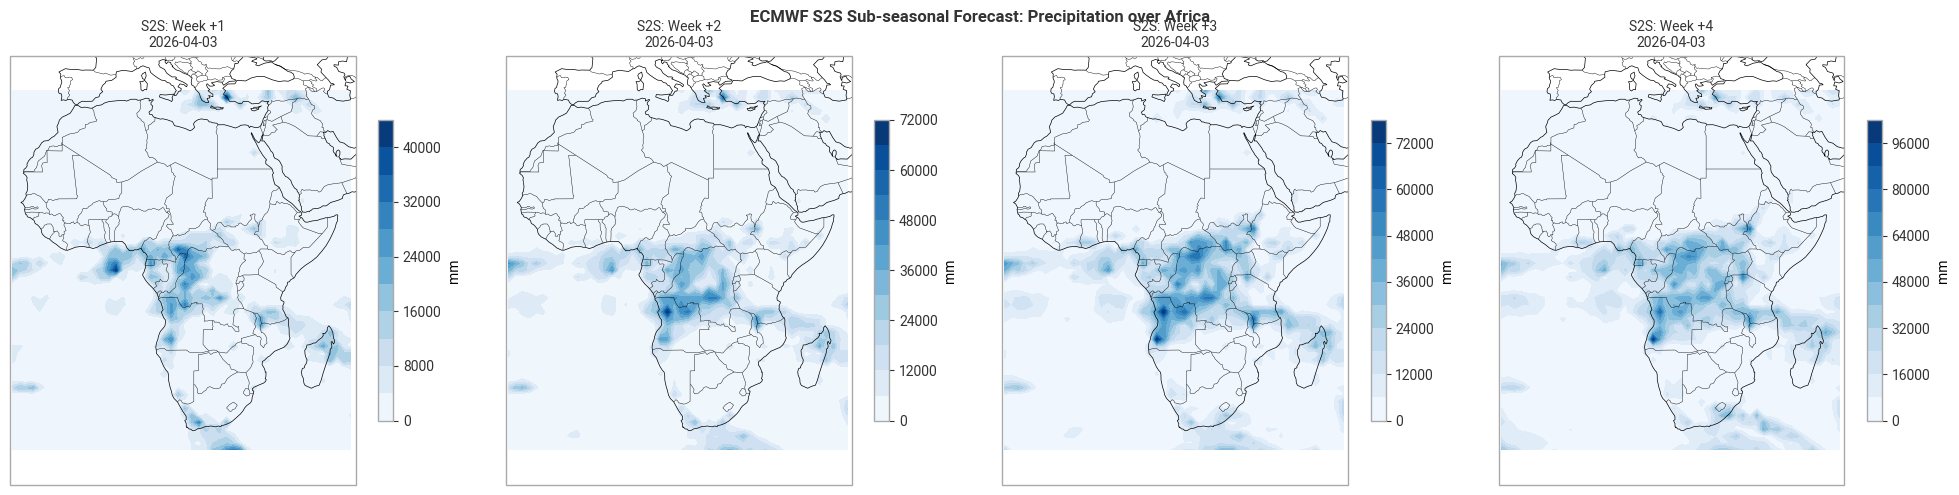

In [11]:
# Plot S2S ensemble mean for each lead week
# Dimension names may vary: we detect them dynamically
step_dim = [d for d in s2s_tp.dims if 'step' in d.lower() or 'lead' in d.lower() or 'fore' in d.lower()][0]
n_steps = s2s_tp.sizes[step_dim]
n_plots = min(n_steps, 4)

fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5),
    subplot_kw={'projection': ccrs.PlateCarree()})

if n_plots == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    field = s2s_tp.isel({step_dim: i}) * 1000  # m → mm
    # If there's a number/member dim, take mean
    for dim in field.dims:
        if 'number' in dim or 'member' in dim:
            field = field.mean(dim=dim)

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    lats = field.latitude if 'latitude' in field.coords else field.lat
    lons = field.longitude if 'longitude' in field.coords else field.lon

    im = ax.contourf(lons, lats, field,
        levels=12, cmap='Blues', transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, label='mm', shrink=0.7)
    ax.set_title(f'S2S: Week +{i+1}\n{S2S_DATE}', fontsize=10)
    ax.set_extent([-20, 55, -40, 40])

plt.suptitle('ECMWF S2S Sub-seasonal Forecast: Precipitation over Africa',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### S2S + SEAS5 together: the anticipatory action chain

In practice, an early warning system uses all timescales together:

```
SEAS5 (months ahead)  →  Is a drought season likely? → pre-position resources
    ↓
S2S (weeks ahead)     →  Which weeks are driest?     → activate protocols
    ↓
IFS/AIFS (days ahead) →  When exactly?               → issue warnings
    ↓
AMSAF nowcast         →  Where right now?             → emergency response
```

Each layer narrows the uncertainty and increases the specificity of the action.
SEWA pilot projects will develop workflows that integrate across these timescales.


## Take-home messages

- **SEAS5** (seasonal, 1-7 months): 51-member ensemble, precipitation anomalies, drought/flood season outlooks
- **S2S** (sub-seasonal, 2-6 weeks): ECMWF contribution to WMO S2S database, weekly outlooks for anticipatory action
- Both are free via CDS: same `cdsapi` client, accept dataset licence once per dataset
- Anomalies vs ERA5 climatology reveal where conditions deviate from normal
- Ensemble spread = confidence: wide spread = uncertain, narrow spread = stronger signal
- For SEWA: these are the **anticipatory action** layers: acting before impact, not after

---

### Next steps
- **07**: CAMS dust aerosol over West Africa (atmosphere monitoring)
- **03**: Medium-range IFS/AIFS (0-15 days, operational)
- **08**: SOFF for higher-resolution LAM initialisation

### Support
- S2S database: [apps.ecmwf.int/datasets/data/s2s](https://apps.ecmwf.int/datasets/data/s2s)
- CDS seasonal: search `seasonal-monthly-single-levels`
- Questions: [support.ecmwf.int](https://support.ecmwf.int)
